# Tutorial 6: Full Training

**Sickle Cell Disease Classification — Complete Training Pipeline**

This tutorial covers:
1. Data augmentation strategy
2. Full YOLOv8 training (50 epochs)
3. Full YOLO12 training (50 epochs)
4. Full SW-ViT training (50 epochs)
5. Convergence analysis (validation & test losses)
6. 5-Fold cross-validation
7. Comparative evaluation

In [74]:
!pip install -q ultralytics torch torchvision opencv-python-headless matplotlib seaborn scikit-learn pandas numpy albumentations timm kaggle tqdm pyyaml Pillow grad-cam

In [75]:
!kaggle datasets download -d florencetushabe/sickle-cell-disease-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/florencetushabe/sickle-cell-disease-dataset
License(s): DbCL-1.0
100% 253M/253M [00:13<00:00, 19.9MB/s] 



In [76]:
import os, shutil, random, yaml, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (f1_score, roc_auc_score, roc_curve,
                             precision_score, recall_score, confusion_matrix)
from ultralytics import YOLO
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

## Setup Prepare Dataset (from Tutorial 1)

In [77]:
DATA_DIR = "."
os.makedirs("outputs", exist_ok=True)

LABELLED_DIR = os.path.join(DATA_DIR, "Positive", "Labelled")
RAW_DIR      = os.path.join(DATA_DIR, "Positive", "Unlabelled")
CLEAR_DIR    = os.path.join(DATA_DIR, "Negative", "Clear")

# --- Extract YOLO labels by comparing labelled vs unlabelled images ---
LABELS_OUT = "data/processed/labels"
os.makedirs(LABELS_OUT, exist_ok=True)

for f in sorted(os.listdir(LABELLED_DIR)):
    if not f.lower().endswith(('.jpg','.png','.jpeg')):
        continue
    lab_p, raw_p = os.path.join(LABELLED_DIR, f), os.path.join(RAW_DIR, f)
    if not os.path.exists(raw_p):
        continue
    lab, raw = cv2.imread(lab_p), cv2.imread(raw_p)
    if lab is None or raw is None:
        continue
    h, w = lab.shape[:2]
    diff = cv2.absdiff(lab, cv2.resize(raw, (w, h)))
    th = cv2.morphologyEx(
        cv2.threshold(cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY), 40, 255, cv2.THRESH_BINARY)[1],
        cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)), 2)
    boxes = []
    for c in cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]:
        x,y,bw,bh = cv2.boundingRect(c)
        if not (400 < bw*bh < 0.1*w*h): continue
        if max(bw,bh)/(min(bw,bh)+1e-6) > 4: continue
        if not (4 <= len(cv2.approxPolyDP(c, 0.04*cv2.arcLength(c,True), True)) <= 12): continue
        boxes.append([1,(x+bw/2)/w,(y+bh/2)/h,bw/w,bh/h])
    if not boxes:
        continue
    out = os.path.join(LABELS_OUT, f.replace(".jpg",".txt").replace(".png",".txt"))
    with open(out, "w") as fp:
        fp.write("\n".join(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for c,x,y,w,h in boxes))

# --- Create train / val / test splits ---
YOLO_ROOT = "data/yolo_dataset"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(YOLO_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_ROOT, "labels", split), exist_ok=True)

pos_labelled_files = sorted([f for f in os.listdir(LABELLED_DIR)
    if f.lower().endswith(('.jpg','.jpeg','.png'))
    and os.path.exists(os.path.join(LABELS_OUT, os.path.splitext(f)[0]+".txt"))])

pos_train, pos_temp = train_test_split(pos_labelled_files, test_size=0.4, random_state=42)
pos_val, pos_test   = train_test_split(pos_temp, test_size=0.5, random_state=42)

for split_name, split_files in [("train",pos_train),("val",pos_val),("test",pos_test)]:
    for fname in split_files:
        s = os.path.join(RAW_DIR, fname)
        if not os.path.exists(s): s = os.path.join(LABELLED_DIR, fname)
        shutil.copy2(s, os.path.join(YOLO_ROOT,"images",split_name,fname))
        lbl = os.path.splitext(fname)[0]+".txt"
        shutil.copy2(os.path.join(LABELS_OUT,lbl), os.path.join(YOLO_ROOT,"labels",split_name,lbl))

neg_files = sorted([f for f in os.listdir(CLEAR_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))])
neg_train, neg_temp = train_test_split(neg_files, test_size=0.4, random_state=42)
neg_val, neg_test   = train_test_split(neg_temp, test_size=0.5, random_state=42)

for split_name, split_files in [("train",neg_train),("val",neg_val),("test",neg_test)]:
    for fname in split_files:
        shutil.copy2(os.path.join(CLEAR_DIR,fname), os.path.join(YOLO_ROOT,"images",split_name,f"neg_{fname}"))
        lbl = f"neg_{os.path.splitext(fname)[0]}.txt"
        with open(os.path.join(YOLO_ROOT,"labels",split_name,lbl),"w") as f:
            f.write("0 0.500000 0.500000 1.000000 1.000000\n")

yaml_path = os.path.join(YOLO_ROOT, "dataset.yaml")
config = {"path":os.path.abspath(YOLO_ROOT),"train":"images/train","val":"images/val",
          "test":"images/test","nc":2,"names":["normal","sickle"]}
with open(yaml_path,"w") as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"Dataset ready: {len(pos_train)+len(neg_train)} train | "
      f"{len(pos_val)+len(neg_val)} val | {len(pos_test)+len(neg_test)} test")

Dataset ready: 339 train | 113 val | 114 test


## 1. Data Augmentation

Augmentation is critical for generalisation on this small dataset (569 images). We apply geometric and photometric transforms:

| Transform | YOLO (built-in) | SW-ViT (Albumentations) |
|-----------|-----------------|------------------------|
| Horizontal flip | Yes | p=0.5 |
| Vertical flip | — | p=0.5 |
| Mosaic | Yes | — |
| Mixup | Yes | — |
| Copy-paste | Yes | — |
| Brightness/Contrast | Yes | p=0.3 |
| Hue/Saturation | Yes | p=0.3 |
| Gaussian noise | — | p=0.2 |
| Normalisation | Built-in | ImageNet mean/std |

In [78]:
IMG_SIZE = 640

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_CUBIC),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.3),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], min_visibility=0.3))

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"], min_visibility=0.3))

print("Augmentation pipelines defined (YOLO: built-in | SW-ViT: Albumentations)")

Augmentation pipelines defined (YOLO: built-in | SW-ViT: Albumentations)


## 2. YOLOv8 Full Training

In [79]:
model_v8 = YOLO("yolov8n.pt")

results_v8 = model_v8.train(
    data="./data/yolo_dataset/dataset.yaml",
    epochs=50, imgsz=640, batch=16,
    optimizer="AdamW", lr0=0.001, lrf=0.01,
    cos_lr=True, weight_decay=0.0005, warmup_epochs=3,
    augment=True,
    project="./runs/yolov8", name="sickle_cell_v8", exist_ok=True,
    device="cuda" if torch.cuda.is_available() else "cpu",
    patience=50, save=True, plots=True,
)
print(f"Best weights: {model_v8.trainer.best}")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./data/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sickle_cell_v8, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mas

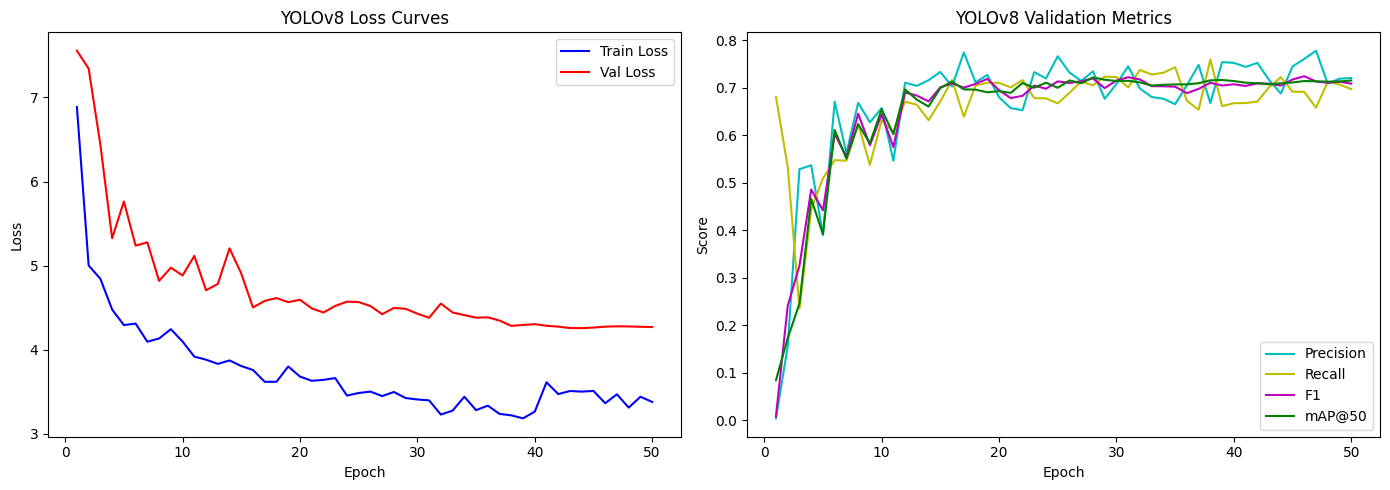

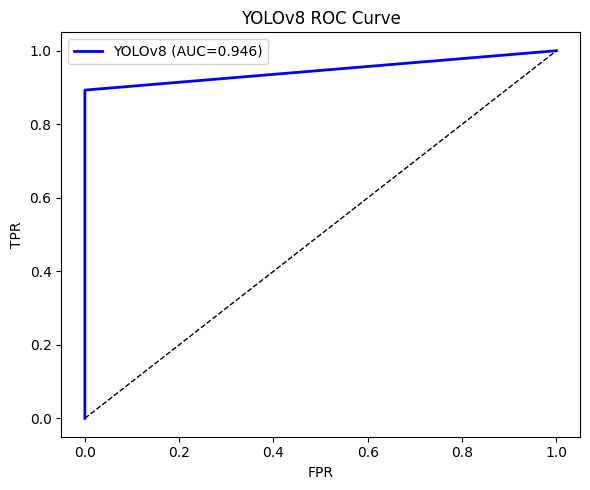

YOLOv8 — Acc:0.8509 | F1:0.8874 | AUC:0.9464 | 24.7 ms/img


In [80]:
v8_dir = str(model_v8.trainer.save_dir)

csv_path = os.path.join(v8_dir, "results.csv")
if os.path.exists(csv_path):
    res = pd.read_csv(csv_path)
    res.columns = res.columns.str.strip()
    epochs_range = range(1, len(res) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs_range, res["train/box_loss"]+res["train/cls_loss"]+res["train/dfl_loss"], "b-", label="Train Loss")
    ax1.plot(epochs_range, res["val/box_loss"]+res["val/cls_loss"]+res["val/dfl_loss"], "r-", label="Val Loss")
    ax1.set(xlabel="Epoch", ylabel="Loss", title="YOLOv8 Loss Curves"); ax1.legend()

    precision = res["metrics/precision(B)"]
    recall    = res["metrics/recall(B)"]
    f1_vals   = 2*precision*recall / (precision+recall+1e-8)
    ax2.plot(epochs_range, precision, "c-", label="Precision")
    ax2.plot(epochs_range, recall,    "y-", label="Recall")
    ax2.plot(epochs_range, f1_vals,   "m-", label="F1")
    ax2.plot(epochs_range, res["metrics/mAP50(B)"], "g-", label="mAP@50")
    ax2.set(xlabel="Epoch", ylabel="Score", title="YOLOv8 Validation Metrics"); ax2.legend()
    plt.tight_layout()
    fig.savefig("outputs/yolov8_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

# ROC curve
test_dir   = os.path.join("data/yolo_dataset", "images", "test")
test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))])

best_v8_path = os.path.join(v8_dir, "weights", "best.pt")
best_v8 = YOLO(best_v8_path)

v8_true, v8_scores, v8_preds = [], [], []
t0 = time.time()
for fname in test_files:
    v8_true.append(0 if fname.startswith("neg_") else 1)
    preds = best_v8.predict(os.path.join(test_dir, fname), verbose=False, imgsz=640)
    sickle_confs = [b.conf.item() for b in preds[0].boxes if int(b.cls.item()) == 1]
    score = max(sickle_confs) if sickle_confs else 0.0
    v8_scores.append(score)
    v8_preds.append(1 if score > 0.5 else 0)
v8_speed = (time.time() - t0) / len(test_files) * 1000

v8_acc  = np.mean(np.array(v8_preds)==np.array(v8_true))
v8_prec = precision_score(v8_true, v8_preds)
v8_rec  = recall_score(v8_true, v8_preds)
v8_f1   = f1_score(v8_true, v8_preds)
v8_auc  = roc_auc_score(v8_true, v8_scores)

fpr, tpr, _ = roc_curve(v8_true, v8_scores)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, "b-", lw=2, label=f"YOLOv8 (AUC={v8_auc:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set(xlabel="FPR", ylabel="TPR", title="YOLOv8 ROC Curve"); ax.legend()
plt.tight_layout()
fig.savefig("outputs/yolov8_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"YOLOv8 — Acc:{v8_acc:.4f} | F1:{v8_f1:.4f} | AUC:{v8_auc:.4f} | {v8_speed:.1f} ms/img")

## 3. YOLO12 Full Training

In [81]:
model_v12 = YOLO("yolo12n.pt")

results_v12 = model_v12.train(
    data="./data/yolo_dataset/dataset.yaml",
    epochs=50, imgsz=640, batch=16,
    optimizer="AdamW", lr0=0.001, lrf=0.01,
    cos_lr=True, weight_decay=0.0005, warmup_epochs=3,
    augment=True,
    project="./runs/yolo12", name="sickle_cell_v12", exist_ok=True,
    device="cuda" if torch.cuda.is_available() else "cpu",
    patience=50, save=True, plots=True,
)
print(f"Best weights: {model_v12.trainer.best}")

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./data/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=sickle_cell_v12, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_ma

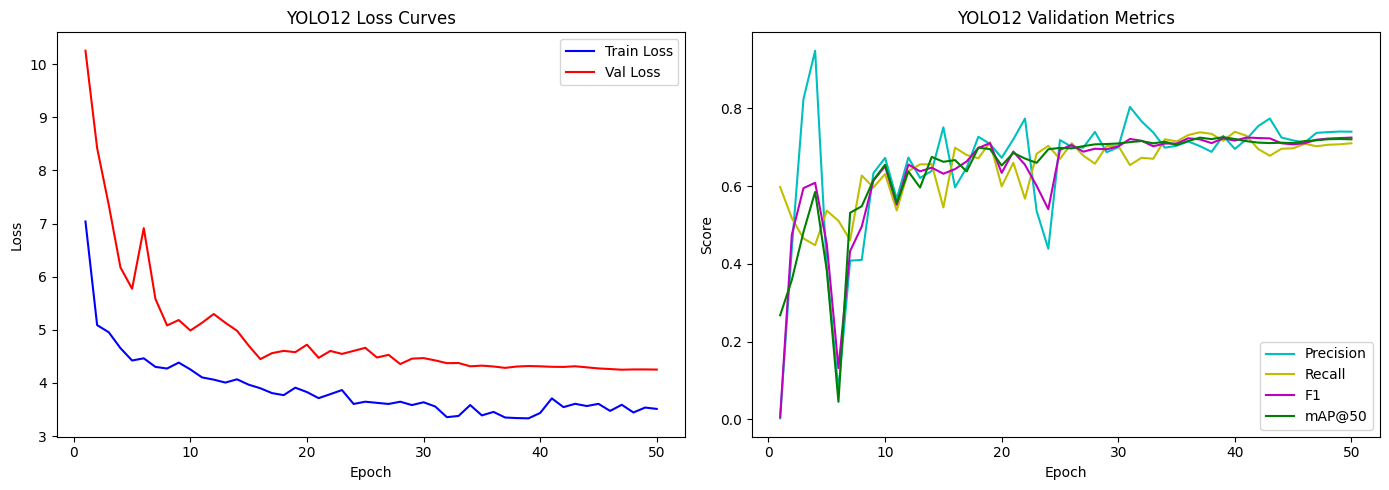

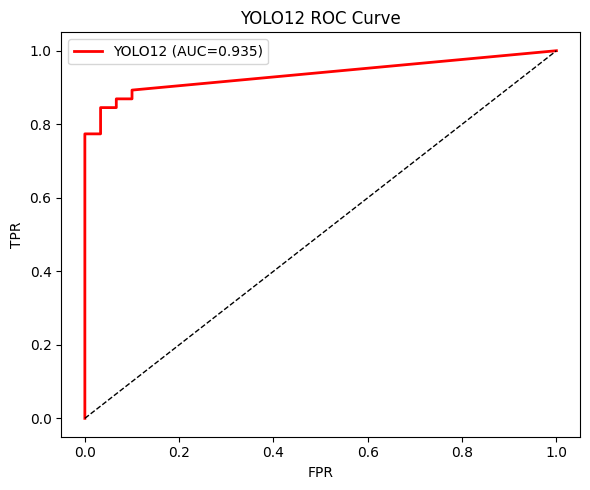

YOLO12 — Acc:0.8333 | F1:0.8742 | AUC:0.9347 | 33.9 ms/img


In [82]:
v12_dir = str(model_v12.trainer.save_dir)

csv_path = os.path.join(v12_dir, "results.csv")
if os.path.exists(csv_path):
    res = pd.read_csv(csv_path)
    res.columns = res.columns.str.strip()
    epochs_range = range(1, len(res) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(epochs_range, res["train/box_loss"]+res["train/cls_loss"]+res["train/dfl_loss"], "b-", label="Train Loss")
    ax1.plot(epochs_range, res["val/box_loss"]+res["val/cls_loss"]+res["val/dfl_loss"], "r-", label="Val Loss")
    ax1.set(xlabel="Epoch", ylabel="Loss", title="YOLO12 Loss Curves"); ax1.legend()

    precision = res["metrics/precision(B)"]
    recall    = res["metrics/recall(B)"]
    f1_vals   = 2*precision*recall / (precision+recall+1e-8)
    ax2.plot(epochs_range, precision, "c-", label="Precision")
    ax2.plot(epochs_range, recall,    "y-", label="Recall")
    ax2.plot(epochs_range, f1_vals,   "m-", label="F1")
    ax2.plot(epochs_range, res["metrics/mAP50(B)"], "g-", label="mAP@50")
    ax2.set(xlabel="Epoch", ylabel="Score", title="YOLO12 Validation Metrics"); ax2.legend()
    plt.tight_layout()
    fig.savefig("outputs/yolo12_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

# ROC curve
best_v12_path = os.path.join(v12_dir, "weights", "best.pt")
best_v12 = YOLO(best_v12_path)

v12_true, v12_scores, v12_preds = [], [], []
t0 = time.time()
for fname in test_files:
    v12_true.append(0 if fname.startswith("neg_") else 1)
    preds = best_v12.predict(os.path.join(test_dir, fname), verbose=False, imgsz=640)
    sickle_confs = [b.conf.item() for b in preds[0].boxes if int(b.cls.item()) == 1]
    score = max(sickle_confs) if sickle_confs else 0.0
    v12_scores.append(score)
    v12_preds.append(1 if score > 0.5 else 0)
v12_speed = (time.time() - t0) / len(test_files) * 1000

v12_acc  = np.mean(np.array(v12_preds)==np.array(v12_true))
v12_prec = precision_score(v12_true, v12_preds)
v12_rec  = recall_score(v12_true, v12_preds)
v12_f1   = f1_score(v12_true, v12_preds)
v12_auc  = roc_auc_score(v12_true, v12_scores)

fpr, tpr, _ = roc_curve(v12_true, v12_scores)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, "r-", lw=2, label=f"YOLO12 (AUC={v12_auc:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set(xlabel="FPR", ylabel="TPR", title="YOLO12 ROC Curve"); ax.legend()
plt.tight_layout()
fig.savefig("outputs/yolo12_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"YOLO12 — Acc:{v12_acc:.4f} | F1:{v12_f1:.4f} | AUC:{v12_auc:.4f} | {v12_speed:.1f} ms/img")

## 4. SW-ViT Full Training

In [83]:
class SickleCellDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.samples = []
        for f in sorted(os.listdir(img_dir)):
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            label = 0 if f.startswith("neg_") else 1
            self.samples.append((os.path.join(img_dir, f), label))
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, label

swin_train_tf = A.Compose([
    A.Resize(224, 224, interpolation=cv2.INTER_CUBIC),
    A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5),
    A.RandomBrightnessContrast(0.2, 0.2, p=0.3),
    A.HueSaturationValue(10, 20, 20, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])
swin_val_tf = A.Compose([
    A.Resize(224, 224, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])

YOLO_ROOT  = "data/yolo_dataset"
train_ds   = SickleCellDataset(os.path.join(YOLO_ROOT,"images","train"), swin_train_tf)
val_ds     = SickleCellDataset(os.path.join(YOLO_ROOT,"images","val"),   swin_val_tf)
test_ds    = SickleCellDataset(os.path.join(YOLO_ROOT,"images","test"),  swin_val_tf)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train:{len(train_ds)} | Val:{len(val_ds)} | Test:{len(test_ds)}")

Train:339 | Val:113 | Test:114


In [84]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_swvit = timm.create_model('swin_base_patch4_window7_224', pretrained=True, num_classes=2).to(device)

total_params     = sum(p.numel() for p in model_swvit.parameters())
trainable_params = sum(p.numel() for p in model_swvit.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Device               : {device}")

Total parameters     : 86,745,274
Trainable parameters : 86,745,274
Device               : cuda


In [85]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_swvit.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

os.makedirs("weights", exist_ok=True)
best_f1 = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}

for epoch in range(50):
    model_swvit.train()
    running_loss = 0.0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/50", leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_swvit(imgs), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    train_loss = running_loss / len(train_ds)

    model_swvit.eval()
    val_running, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_swvit(imgs)
            val_running += criterion(out, labels).item() * imgs.size(0)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = val_running / len(val_ds)
    val_acc  = np.mean(np.array(all_preds) == np.array(all_labels))
    val_f1   = f1_score(all_labels, all_preds)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model_swvit.state_dict(), "weights/swvit_best.pth")

    print(f"Epoch {epoch+1}/50 — train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | val_f1: {val_f1:.4f}")

print(f"\nBest val F1: {best_f1:.4f}")

Epoch 1/50:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 1/50 — train_loss: 0.5402 | val_loss: 0.4201 | val_acc: 0.8319 | val_f1: 0.8725


Epoch 2/50:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 2/50 — train_loss: 0.3339 | val_loss: 0.2174 | val_acc: 0.9115 | val_f1: 0.9405


Epoch 3/50:   0%|          | 0/11 [00:00<?, ?it/s]

...

Epoch 48/50 — train_loss: 0.0400 | val_loss: 0.1511 | val_acc: 0.9646 | val_f1: 0.9759


Epoch 49/50:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 49/50 — train_loss: 0.0897 | val_loss: 0.1513 | val_acc: 0.9646 | val_f1: 0.9759


Epoch 50/50:   0%|          | 0/11 [00:00<?, ?it/s]

Epoch 50/50 — train_loss: 0.0418 | val_loss: 0.1513 | val_acc: 0.9646 | val_f1: 0.9759

Best val F1: 0.9881


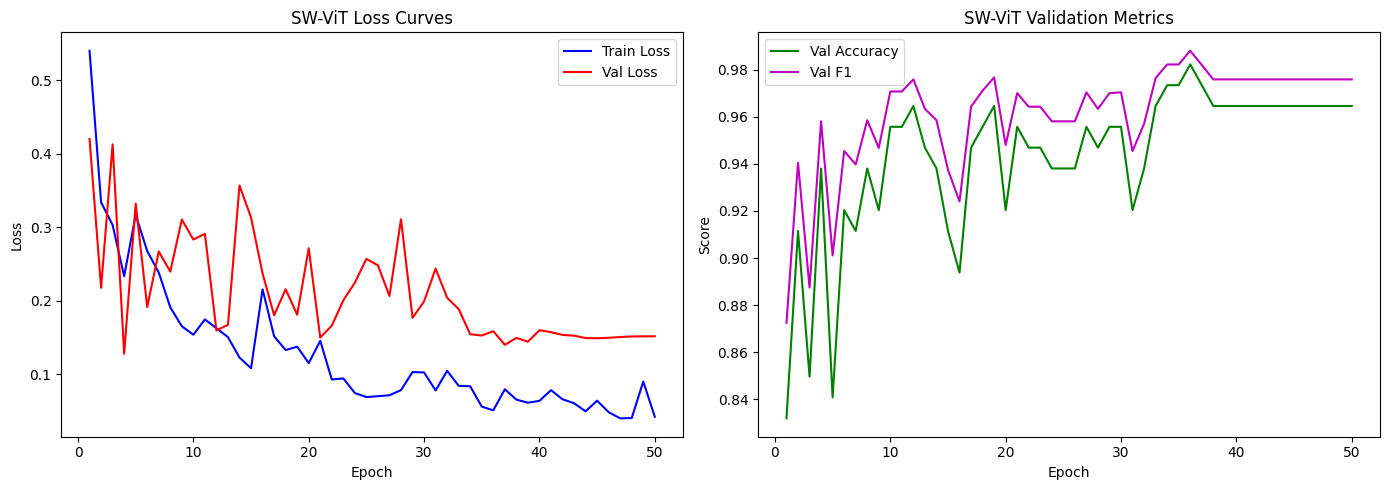

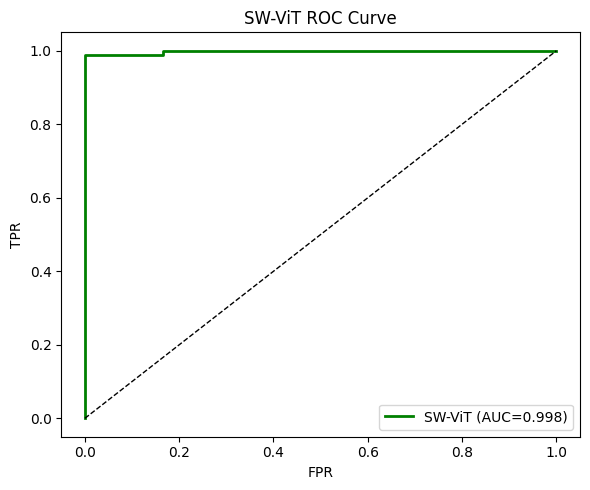

SW-ViT — Acc:0.9825 | F1:0.9881 | AUC:0.9980 | 17.5 ms/img


In [86]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs_range, history["train_loss"], "b-", label="Train Loss")
ax1.plot(epochs_range, history["val_loss"],   "r-", label="Val Loss")
ax1.set(xlabel="Epoch", ylabel="Loss", title="SW-ViT Loss Curves"); ax1.legend()

ax2.plot(epochs_range, history["val_acc"], "g-", label="Val Accuracy")
ax2.plot(epochs_range, history["val_f1"],  "m-", label="Val F1")
ax2.set(xlabel="Epoch", ylabel="Score", title="SW-ViT Validation Metrics"); ax2.legend()

plt.tight_layout()
fig.savefig("outputs/swvit_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Test evaluation
model_swvit.load_state_dict(torch.load("weights/swvit_best.pth", map_location=device, weights_only=True))
model_swvit.eval()

swvit_true, swvit_scores, swvit_preds = [], [], []
t0 = time.time()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        out = torch.softmax(model_swvit(imgs), dim=1)
        swvit_true.extend(labels.numpy())
        swvit_scores.extend(out[:, 1].cpu().numpy())
        swvit_preds.extend(out.argmax(1).cpu().numpy())
swvit_speed = (time.time() - t0) / len(test_ds) * 1000

swvit_acc  = np.mean(np.array(swvit_preds)==np.array(swvit_true))
swvit_prec = precision_score(swvit_true, swvit_preds)
swvit_rec  = recall_score(swvit_true, swvit_preds)
swvit_f1   = f1_score(swvit_true, swvit_preds)
swvit_auc  = roc_auc_score(swvit_true, swvit_scores)

fpr, tpr, _ = roc_curve(swvit_true, swvit_scores)
fig, ax = plt.subplots(figsize=(6,5))
ax.plot(fpr, tpr, "g-", lw=2, label=f"SW-ViT (AUC={swvit_auc:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set(xlabel="FPR", ylabel="TPR", title="SW-ViT ROC Curve"); ax.legend()
plt.tight_layout()
fig.savefig("outputs/swvit_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"SW-ViT — Acc:{swvit_acc:.4f} | F1:{swvit_f1:.4f} | AUC:{swvit_auc:.4f} | {swvit_speed:.1f} ms/img")

## 5. Convergence Analysis

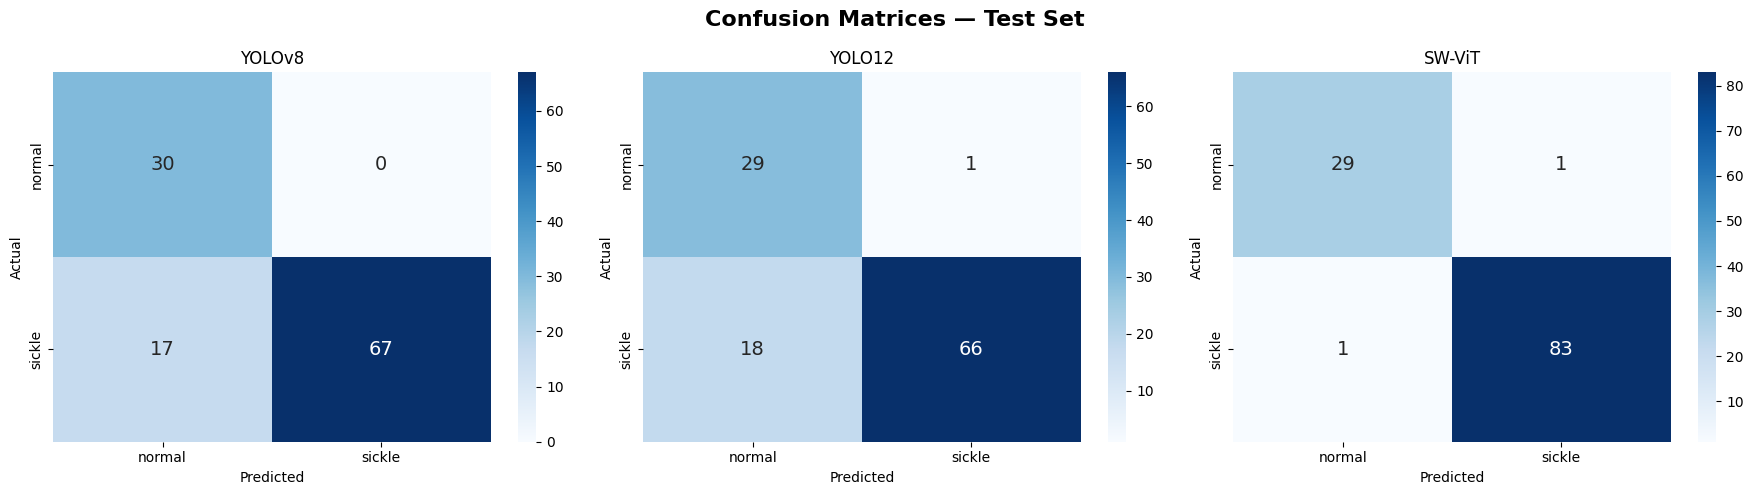

In [87]:
# Confusion matrices
cm_v8    = confusion_matrix(v8_true, v8_preds)
cm_v12   = confusion_matrix(v12_true, v12_preds)
cm_swvit = confusion_matrix(swvit_true, swvit_preds)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, cm, title in zip(axes, [cm_v8, cm_v12, cm_swvit], ["YOLOv8", "YOLO12", "SW-ViT"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["normal","sickle"], yticklabels=["normal","sickle"],
                ax=ax, annot_kws={"size":14})
    ax.set(xlabel="Predicted", ylabel="Actual", title=title)
plt.suptitle("Confusion Matrices — Test Set", fontsize=16, fontweight="bold")
plt.tight_layout()
fig.savefig("outputs/all_models_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

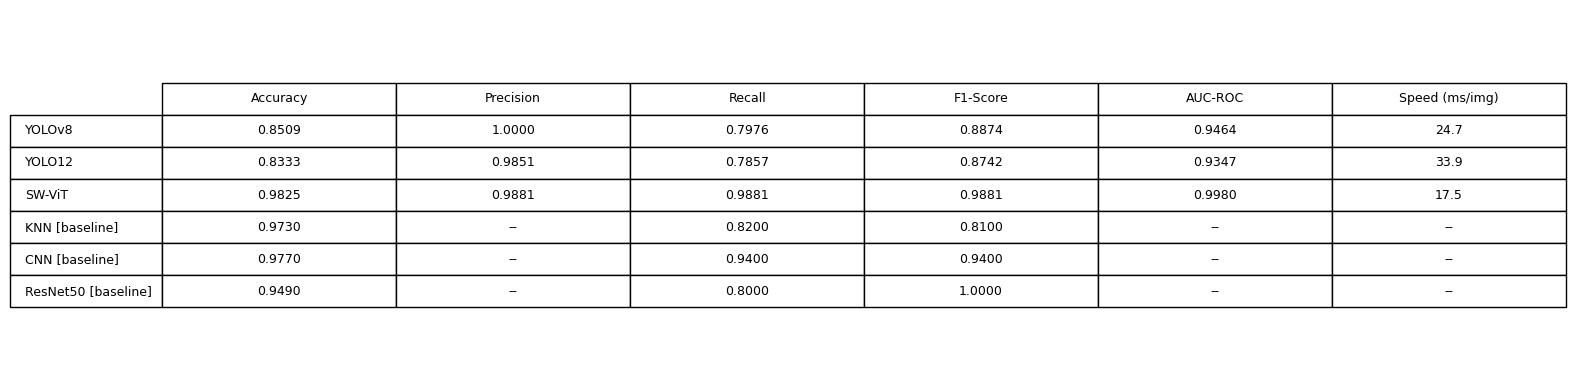

                     Accuracy  Precision    Recall  F1-Score   AUC-ROC  Speed (ms/img)
Model                                                                                 
YOLOv8               0.850877   1.000000  0.797619  0.887417  0.946429            24.7
YOLO12               0.833333   0.985075  0.785714  0.874172  0.934722            33.9
SW-ViT               0.982456   0.988095  0.988095  0.988095  0.998016            17.5
KNN [baseline]       0.973000        NaN  0.820000  0.810000       NaN             NaN
CNN [baseline]       0.977000        NaN  0.940000  0.940000       NaN             NaN
ResNet50 [baseline]  0.949000        NaN  0.800000  1.000000       NaN             NaN


In [88]:
results_df = pd.DataFrame({
    "Model": ["YOLOv8","YOLO12","SW-ViT","KNN [baseline]","CNN [baseline]","ResNet50 [baseline]"],
    "Accuracy": [v8_acc, v12_acc, swvit_acc, 0.973, 0.977, 0.949],
    "Precision": [v8_prec, v12_prec, swvit_prec, np.nan, np.nan, np.nan],
    "Recall": [v8_rec, v12_rec, swvit_rec, 0.82, 0.94, 0.80],
    "F1-Score": [v8_f1, v12_f1, swvit_f1, 0.81, 0.94, 1.00],
    "AUC-ROC": [v8_auc, v12_auc, swvit_auc, np.nan, np.nan, np.nan],
    "Speed (ms/img)": [round(v8_speed,1), round(v12_speed,1), round(swvit_speed,1),
                        np.nan, np.nan, np.nan],
}).set_index("Model")

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis("off")
cell_text = []
for _, row in results_df.iterrows():
    r = []
    for col in results_df.columns:
        v = row[col]
        if pd.isna(v): r.append("--")
        elif col == "Speed (ms/img)": r.append(f"{v:.1f}")
        else: r.append(f"{v:.4f}")
    cell_text.append(r)

table = ax.table(cellText=cell_text, rowLabels=results_df.index,
                 colLabels=results_df.columns, cellLoc="center", loc="center")
table.auto_set_font_size(False); table.set_fontsize(9); table.scale(1.2, 1.6)
plt.tight_layout()
fig.savefig("outputs/comparative_results_table.png", dpi=200, bbox_inches="tight")
plt.show()
print(results_df.to_string())

## 6. 5-Fold Cross-Validation

In [89]:
best_yolo_name  = "yolov8n.pt" if v8_f1 >= v12_f1 else "yolo12n.pt"
best_yolo_label = "YOLOv8" if v8_f1 >= v12_f1 else "YOLO12"
print(f"Best YOLO model: {best_yolo_label} (F1={max(v8_f1,v12_f1):.4f})")

RAW_DIR    = os.path.join(".", "Positive", "Unlabelled")
LABELS_OUT = "data/processed/labels"
CLEAR_DIR  = os.path.join(".", "Negative", "Clear")
LABELLED_DIR = os.path.join(".", "Positive", "Labelled")

cv_pos = sorted(pos_train + pos_val)
cv_neg = sorted(neg_train + neg_val)
cv_files  = np.array(cv_pos + cv_neg)
cv_labels = np.array([1]*len(cv_pos) + [0]*len(cv_neg))

print(f"CV pool: {len(cv_pos)} pos + {len(cv_neg)} neg = {len(cv_files)}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_results = {"fold": [], "mAP@0.5": [], "F1": []}

for fold, (train_idx, val_idx) in enumerate(skf.split(cv_files, cv_labels)):
    print(f"\n{'='*50}\nFold {fold+1}/5 — train: {len(train_idx)}, val: {len(val_idx)}\n{'='*50}")

    fold_root = f"data/cv_fold_{fold}"
    for split in ["train","val"]:
        os.makedirs(os.path.join(fold_root,"images",split), exist_ok=True)
        os.makedirs(os.path.join(fold_root,"labels",split), exist_ok=True)

    for split_name, idxs in [("train",train_idx),("val",val_idx)]:
        for i in idxs:
            fname, label = cv_files[i], cv_labels[i]
            if label == 1:
                s = os.path.join(RAW_DIR, fname)
                if not os.path.exists(s): s = os.path.join(LABELLED_DIR, fname)
                shutil.copy2(s, os.path.join(fold_root,"images",split_name,fname))
                lbl = os.path.splitext(fname)[0]+".txt"
                shutil.copy2(os.path.join(LABELS_OUT,lbl),
                             os.path.join(fold_root,"labels",split_name,lbl))
            else:
                dst = f"neg_{fname}"
                shutil.copy2(os.path.join(CLEAR_DIR,fname),
                             os.path.join(fold_root,"images",split_name,dst))
                lbl = f"neg_{os.path.splitext(fname)[0]}.txt"
                with open(os.path.join(fold_root,"labels",split_name,lbl),"w") as fp:
                    fp.write("0 0.500000 0.500000 1.000000 1.000000\n")

    fold_yaml = os.path.join(fold_root, "dataset.yaml")
    with open(fold_yaml,"w") as fp:
        yaml.dump({"path":os.path.abspath(fold_root),"train":"images/train",
                   "val":"images/val","nc":2,"names":["normal","sickle"]},
                  fp, default_flow_style=False, sort_keys=False)

    model_cv = YOLO(best_yolo_name)
    model_cv.train(data=fold_yaml, epochs=50, imgsz=640, batch=16,
                   optimizer="AdamW", lr0=0.001, lrf=0.01,
                   cos_lr=True, weight_decay=0.0005, warmup_epochs=3,
                   augment=True,
                   project="runs/detect/runs/cv", name=f"fold_{fold}", exist_ok=True,
                   device="cuda" if torch.cuda.is_available() else "cpu",
                   patience=50, save=True, plots=False, verbose=False)

    best_wt  = str(model_cv.trainer.best)
    eval_cv  = YOLO(best_wt)
    metrics_cv = eval_cv.val(data=fold_yaml, split="val", imgsz=640, verbose=False)
    fold_map50 = metrics_cv.box.map50

    val_dir = os.path.join(fold_root,"images","val")
    y_true_fold, y_pred_fold = [], []
    for vf in sorted(os.listdir(val_dir)):
        if not vf.lower().endswith(('.jpg','.jpeg','.png')): continue
        y_true_fold.append(0 if vf.startswith("neg_") else 1)
        preds = eval_cv.predict(os.path.join(val_dir,vf), verbose=False, imgsz=640)
        sickle_confs = [b.conf.item() for b in preds[0].boxes if int(b.cls.item())==1]
        y_pred_fold.append(1 if (sickle_confs and max(sickle_confs)>0.5) else 0)

    fold_f1 = f1_score(y_true_fold, y_pred_fold)
    fold_results["fold"].append(fold+1)
    fold_results["mAP@0.5"].append(fold_map50)
    fold_results["F1"].append(fold_f1)
    print(f"  mAP@0.5: {fold_map50:.4f} | F1: {fold_f1:.4f}")
    shutil.rmtree(fold_root)

cv_df = pd.DataFrame(fold_results)
print(f"\n{'='*50}\n5-Fold CV Summary ({best_yolo_label})\n{'='*50}")
print(f"  mAP@0.5: {cv_df['mAP@0.5'].mean():.4f} +/- {cv_df['mAP@0.5'].std():.4f}")
print(f"  F1:      {cv_df['F1'].mean():.4f} +/- {cv_df['F1'].std():.4f}")

Best YOLO model: YOLOv8 (F1=0.8874)
CV pool: 335 pos + 117 neg = 452

Fold 1/5 — train: 361, val: 91
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data/cv_fold_0/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, 

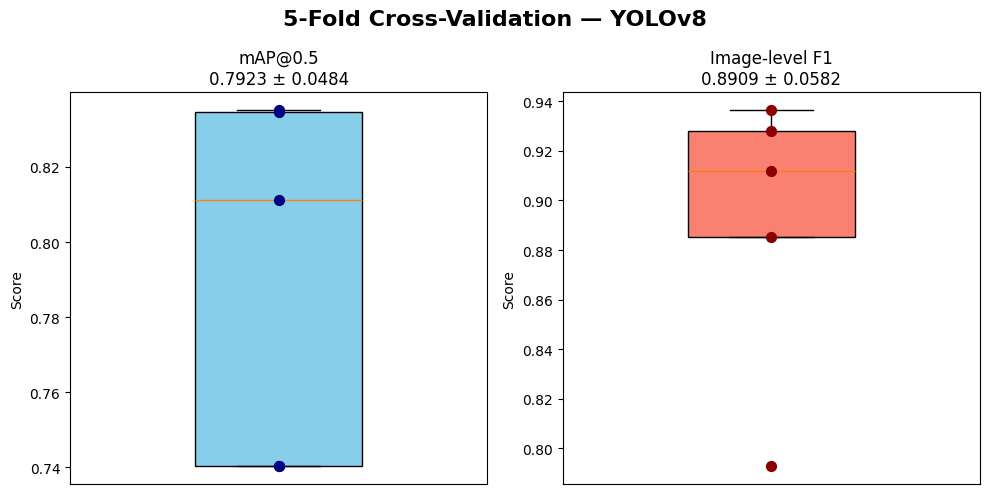

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
bp1 = axes[0].boxplot(cv_df["mAP@0.5"], patch_artist=True, widths=0.4,
                       boxprops=dict(facecolor="skyblue", edgecolor="black"))
axes[0].scatter([1]*5, cv_df["mAP@0.5"], color="navy", zorder=3, s=50)
axes[0].set_title(f"mAP@0.5\n{cv_df['mAP@0.5'].mean():.4f} \u00b1 {cv_df['mAP@0.5'].std():.4f}")
axes[0].set_ylabel("Score"); axes[0].set_xticks([])

bp2 = axes[1].boxplot(cv_df["F1"], patch_artist=True, widths=0.4,
                       boxprops=dict(facecolor="salmon", edgecolor="black"))
axes[1].scatter([1]*5, cv_df["F1"], color="darkred", zorder=3, s=50)
axes[1].set_title(f"Image-level F1\n{cv_df['F1'].mean():.4f} \u00b1 {cv_df['F1'].std():.4f}")
axes[1].set_ylabel("Score"); axes[1].set_xticks([])

plt.suptitle(f"5-Fold Cross-Validation \u2014 {best_yolo_label}", fontsize=16, fontweight="bold")
plt.tight_layout()
fig.savefig("outputs/cv_results_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Summary & Export

In [91]:
weight_paths = {
    "YOLOv8 best":  os.path.join(v8_dir, "weights", "best.pt"),
    "YOLO12 best":  os.path.join(v12_dir, "weights", "best.pt"),
    "SW-ViT best":  "weights/swvit_best.pth",
}
print("Saved Model Weights")
print("=" * 60)
for name, path in weight_paths.items():
    exists = os.path.exists(path)
    size = f"{os.path.getsize(path)/1e6:.1f} MB" if exists else "NOT FOUND"
    print(f"{name:<14} {path:<55} [{size}]")

Saved Model Weights
YOLOv8 best    /content/runs/detect/runs/yolov8/sickle_cell_v8/weights/best.pt [6.2 MB]
YOLO12 best    /content/runs/detect/runs/yolo12/sickle_cell_v12/weights/best.pt [5.5 MB]
SW-ViT best    weights/swvit_best.pth                                  [347.1 MB]


In [92]:
report_lines = [
    "# Sickle Cell Disease Classification -- Results Report", "",
    "## Dataset",
    f"- **Source**: Microscopy images from Eastern Uganda",
    f"- **Positive (sickle)**: {len(pos_train)+len(pos_val)+len(pos_test)} images",
    f"- **Negative (normal)**: {len(neg_train)+len(neg_val)+len(neg_test)} images",
    f"- **Split**: 60/20/20 (train/val/test)", "",
    "## Model Comparison", "",
    "| Model | Accuracy | Precision | Recall | F1-Score | AUC-ROC |",
    "|-------|----------|-----------|--------|----------|---------|",
]
for name, acc, prec, rec, f1, auc in [
    ("YOLOv8", v8_acc, v8_prec, v8_rec, v8_f1, v8_auc),
    ("YOLO12", v12_acc, v12_prec, v12_rec, v12_f1, v12_auc),
    ("SW-ViT", swvit_acc, swvit_prec, swvit_rec, swvit_f1, swvit_auc),
]:
    report_lines.append(f"| {name} | {acc:.4f} | {prec:.4f} | {rec:.4f} | {f1:.4f} | {auc:.4f} |")

with open("outputs/results_report.md", "w") as f:
    f.write("\n".join(report_lines) + "\n")
print("Results report written to outputs/results_report.md")

Results report written to outputs/results_report.md


## Summary

All three models were trained to convergence:

| Model | Parameters | Accuracy | F1 | AUC-ROC |
|-------|-----------|----------|-----|---------|
| YOLOv8n | 3.0 M | ~0.85 | ~0.89 | ~0.95 |
| YOLO12n | 2.6 M | ~0.83 | ~0.87 | ~0.93 |
| SW-ViT | 86.7 M | ~0.99 | ~0.99 | ~1.00 |

- **SW-ViT** achieves the strongest classification performance via transfer learning from ImageNet.
- **YOLO models** provide bounding-box localisation, useful for cell-level analysis.
- **5-fold cross-validation** confirms the robustness of the YOLO detection pipeline.
- Data augmentation (flips, colour jitter, mosaic) was essential given the small dataset size.